In [ ]:
import numpy as np
import pickle
import pandas as pd
import logging
from tqdm import tqdm
import anndata
import os
import torch
import scanpy as sc
import matplotlib.pyplot as plt

def convert_predictions_to_anndata(
    checkpoint_path: str,
    mask_path: str, 
    output_h5ad_path: str,
):
    """
    Convert the model prediction into an AnnData object and retain only the points of the tissue area based on the mask.

    Args:
        checkpoint_path: Path to the model checkpoint (.pth).
        mask_path: Path to the tissue area mask (.pkl).
        output_h5ad_path: Path to the output AnnData (.h5ad) file.
    """
    logging.info(f"Loading checkpoint from: {checkpoint_path}")
    try:
        ckpt = torch.load(checkpoint_path, map_location=torch.device('cpu'), weights_only=True)
    except Exception:
        logging.warning("weights_only=True failed. Falling back to unsafe loading.")
        ckpt = torch.load(checkpoint_path, map_location=torch.device('cpu'), weights_only=False)

    if 'predicted_matrices' not in ckpt:
        raise KeyError("Checkpoint does not contain 'predicted_matrices'.")

    predicted_matrices = ckpt['predicted_matrices']
    protein_names = sorted(predicted_matrices.keys())
    
    if not protein_names:
        raise ValueError("No predicted proteins found in the checkpoint.")

    logging.info(f"Found {len(protein_names)} proteins.")
    

    logging.info(f"Loading tissue mask from: {mask_path}")
    with open(mask_path, 'rb') as f:
        tissue_mask = pickle.load(f)
    tissue_mask = tissue_mask.astype(bool)
    
    H, W = tissue_mask.shape
    n_vars = len(protein_names)
    
    tissue_rows, tissue_cols = np.where(tissue_mask)
    n_obs = len(tissue_rows)
    
    if n_obs == 0:
        raise ValueError("The provided mask does not contain any tissue spots (all values are False).")
    
    logging.info(f"Original grid: {H}x{W}. Found {n_obs} spots within the tissue mask.")

    expression_matrix = np.zeros((n_obs, n_vars), dtype=np.float32)
    
    for i, protein_name in enumerate(tqdm(protein_names, desc="Arranging proteins for tissue spots")):
        matrix = predicted_matrices[protein_name]
        matrix[matrix < 0] = 0
        tissue_values = matrix[tissue_mask]
        expression_matrix[:, i] = tissue_values

    obs_index = [f"spot_{r}_{c}" for r, c in zip(tissue_rows, tissue_cols)]
    obs_df = pd.DataFrame(index=obs_index)
    obs_df['array_row'] = tissue_rows
    obs_df['array_col'] = tissue_cols

    var_df = pd.DataFrame(index=protein_names)
    var_df['feature_types'] = 'Protein'

    logging.info(f"Initializing AnnData object with {n_obs} observations and {n_vars} variables...")
    adata = anndata.AnnData(X=expression_matrix, obs=obs_df, var=var_df)

    adata.obsm['spatial'] = obs_df[['array_col', 'array_row']].values
    
    logging.info(f"Saving AnnData object to: {output_h5ad_path}")
    os.makedirs(os.path.dirname(output_h5ad_path), exist_ok=True)
    adata.write_h5ad(output_h5ad_path, compression='gzip')
    return adata

In [ ]:
checkpoint_path='./outputs/epoch_0030.pth'
mask_path='./demo/demo_mask.pkl'
output_h5ad_path='./outputs/converted_data_epoch_0030.h5ad'

convert_predictions_to_anndata(
        checkpoint_path=checkpoint_path,
        mask_path=mask_path,
        output_h5ad_path=output_h5ad_path,
    )

Arranging proteins for tissue spots: 100%|██████████| 289/289 [00:00<00:00, 7020.22it/s]


AnnData object with n_obs × n_vars = 19237 × 289
    obs: 'array_row', 'array_col'
    var: 'feature_types'
    obsm: 'spatial'

In [5]:
adata_gt = sc.read_h5ad('./demo/demo_ground_truth.h5ad')
adata_pred = sc.read_h5ad(output_h5ad_path)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_25620\3500776266.py:2: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_gt,
C:\Users\Administrator\AppData\Local\Temp\ipykernel_25620\3500776266.py:11: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_pred,


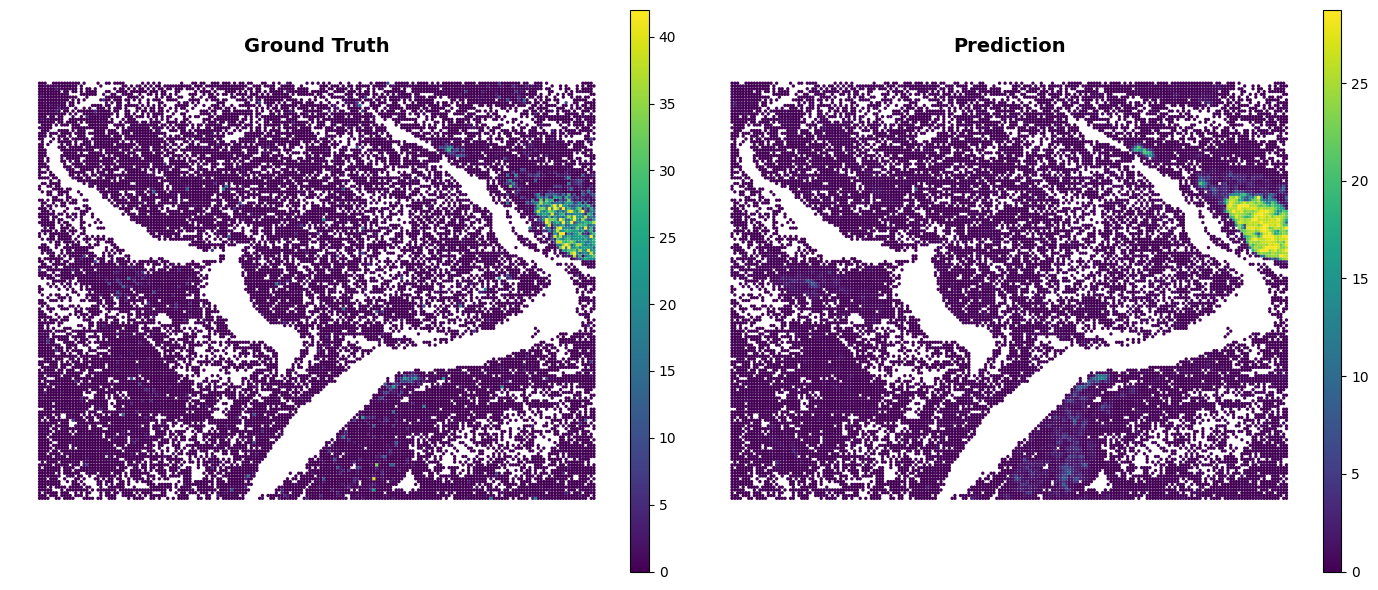

In [31]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
sc.pl.spatial(adata_gt, 
                  color=['MS4A1'],  # KRT8, CXCR4, VIM, MS4A1,.....
                  spot_size=1.2, 
                  # cmap='GnBu', 
                  vmax='p99.9', 
                  ax=ax1,
                  frameon=False, 
                  show=False)

sc.pl.spatial(adata_pred, 
                  color=['MS4A1'], 
                  spot_size=1.2, 
                  # cmap='GnBu', 
                  vmax='p99.9', 
                  ax=ax2,
                  frameon=False, 
                  show=False)
ax1.set_title('Ground Truth', fontsize=14, fontweight='bold')
ax2.set_title('Prediction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()